In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
path = '/content/drive/MyDrive/Colab Notebooks/eye-images-balanced'

In [ ]:
Normal = os.path.join(path,'/content/drive/MyDrive/Colab Notebooks/eye-images-balanced/1_normal/')
Cataract = os.path.join(path,'/content/drive/MyDrive/Colab Notebooks/eye-images-balanced/2_cataract')
Glaucoma = os.path.join(path,'/content/drive/MyDrive/Colab Notebooks/eye-images-balanced/2_glaucoma')
print("Number of uninfected cells", len(os.listdir(Normal)))
print("Number of uninfected cells", len(os.listdir(Cataract)))
print("Number of uninfected cells", len(os.listdir(Glaucoma)))

Number of uninfected cells 300
Number of uninfected cells 300
Number of uninfected cells 300


In [ ]:
import cv2  # used to read images
import numpy as np

def load_images(directories, n_images=900):
    """
    Reads in images and assigns class labels
    Parameters:
        directories: A list of the sub-directories
        n_images:    The maximum number of images to load from each directory
    Returns:
        images (numpy.ndarray) : Image data
        label (numpy.ndarray      : Labels of each image
    """
    images = []
    labels = []
    for label, sub_dir in enumerate(directories):
        num=1
        for file_name in os.listdir(sub_dir):
            if num > n_images:
                break
            img_path = os.path.join(sub_dir, file_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, (100, 100))  # Resize to a smaller, consistent shape
                #gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                #images.append(gray_image)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)
                labels.append(label)  # 0 for Uninfected 1 for Parasitized
                num+=1
    return np.array(images), np.array(labels)

In [ ]:
images, labels = load_images(directories=[Normal, Cataract, Glaucoma], n_images=900)

In [ ]:
images.shape

(900, 100, 100, 3)

In [ ]:
import numpy as np

X_data = []
y_data = []

# Loop through all batches in train_generator
for _ in range(len(train_generator)):
    X_batch, y_batch = train_generator.__next__()  # Fetch batch
    X_data.append(X_batch)
    y_data.append(y_batch)

# Convert to full dataset arrays
X_data = np.vstack(X_data)  # Merge batches
y_data = np.vstack(y_data)  # Merge label batches

# Print final dataset shapes
print("Final X_data shape:", X_data.shape)  # Expected: (720, 100, 100, 3)
print("Final y_data shape:", y_data.shape)  # Expected: (720, 3)



Final X_data shape: (720, 100, 100, 3)
Final y_data shape: (720, 3)


In [ ]:
from tensorflow.keras.utils import to_categorical

# Detect number of classes dynamically
num_classes = y_data.shape[1] if len(y_data.shape) > 1 else len(np.unique(y_data))

# Apply one-hot encoding if needed
if y_data.shape[1] != num_classes:
    y_data = to_categorical(y_data, num_classes=num_classes)

print("Final y_data shape after one-hot encoding:", y_data.shape)  # Expected: (720, 3)


Final y_data shape after one-hot encoding: (720, 3)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset before training
X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Print final shapes
print("X_train shape:", X_train.shape)  # Expected: (576, 100, 100, 3)
print("y_train shape:", y_train.shape)  # Expected: (576, 3)
print("X_val shape:", X_val.shape)  # Expected: (144, 100, 100, 3)
print("y_val shape:", y_val.shape)  # Expected: (144, 3)


X_train shape: (576, 100, 100, 3)
y_train shape: (576, 3)
X_val shape: (144, 100, 100, 3)
y_val shape: (144, 3)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Define dataset path
dataset_path = "/content/drive/MyDrive/Colab Notebooks/eye-images-balanced"

# Load dataset using ImageDataGenerator
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(100, 100),
    batch_size=50,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(100, 100),
    batch_size=50,
    class_mode='categorical',
    subset='validation'
)

# Extract full dataset from generator
X_data, y_data = [], []

for _ in range(len(train_generator)):
    X_batch, y_batch = train_generator.__next__()
    X_data.append(X_batch)
    y_data.append(y_batch)

# Convert to NumPy arrays
X_data = np.vstack(X_data)
y_data = np.vstack(y_data)

# Ensure labels are correctly one-hot encoded
num_classes = y_data.shape[1] if len(y_data.shape) > 1 else len(np.unique(y_data))
if y_data.shape[1] != num_classes:
    y_data = to_categorical(y_data, num_classes=num_classes)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Print final dataset shapes
print("Final X_train shape:", X_train.shape)  # Expected: (576, 100, 100, 3)
print("Final y_train shape:", y_train.shape)  # Expected: (576, 3)
print("Final X_val shape:", X_val.shape)  # Expected: (144, 100, 100, 3)
print("Final y_val shape:", y_val.shape)  # Expected: (144, 3)


Found 720 images belonging to 3 classes.
Found 180 images belonging to 3 classes.
Final X_train shape: (576, 100, 100, 3)
Final y_train shape: (576, 3)
Final X_val shape: (144, 100, 100, 3)
Final y_val shape: (144, 3)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Define dataset path
dataset_path = "/content/drive/MyDrive/Colab Notebooks/eye-images-balanced"

# Load dataset using ImageDataGenerator
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(100, 100),
    batch_size=50,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(100, 100),
    batch_size=50,
    class_mode='categorical',
    subset='validation'
)

# Extract all images and labels from the generator
images, labels = [], []

for _ in range(len(train_generator)):
    X_batch, y_batch = train_generator.__next__()  # Fetch batch
    images.append(X_batch)
    labels.append(y_batch)

# Convert to full dataset arrays
images = np.vstack(images)
labels = np.vstack(labels)

# Ensure labels are correctly one-hot encoded
num_classes = labels.shape[1] if len(labels.shape) > 1 else len(np.unique(labels))
if labels.shape[1] != num_classes:
    labels = to_categorical(labels, num_classes=num_classes)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)

# Print final dataset shapes
print("X_train shape:", X_train.shape)  # Expected: (720, 100, 100, 3)
print("y_train shape:", y_train.shape)  # Expected: (720, 3)
print("X_val shape:", X_val.shape)  # Expected: (180, 100, 100, 3)
print("y_val shape:", y_val.shape)  # Expected: (180, 3)


Found 720 images belonging to 3 classes.
Found 180 images belonging to 3 classes.
X_train shape: (576, 100, 100, 3)
y_train shape: (576, 3)
X_val shape: (144, 100, 100, 3)
y_val shape: (144, 3)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define dataset path
dataset_path = "/content/drive/MyDrive/Colab Notebooks/eye-images-balanced"

# Load dataset using ImageDataGenerator
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(100, 100),
    batch_size=50,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(100, 100),
    batch_size=50,
    class_mode='categorical',
    subset='validation'
)

# Extract full dataset from generator
X_data, y_data = [], []

for _ in range(len(train_generator)):
    X_batch, y_batch = train_generator.__next__()
    X_data.append(X_batch)
    y_data.append(y_batch)

# Convert to NumPy arrays
X_data = np.vstack(X_data)
y_data = np.vstack(y_data)  # Labels now match image count

# Print final shapes
print("Final X_data shape:", X_data.shape)  # Expected: (720, 100, 100, 3)
print("Final y_data shape:", y_data.shape)  # Expected: (720, 3)

# Ensure labels are one-hot encoded
num_classes = y_data.shape[1]
y_data = to_categorical(np.argmax(y_data, axis=1), num_classes=num_classes)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Print final dataset shapes
print("X_train shape:", X_train.shape)  # Expected: (576, 100, 100, 3)
print("y_train shape:", y_train.shape)  # Expected: (576, 3)
print("X_val shape:", X_val.shape)  # Expected: (144, 100, 100, 3)
print("y_val shape:", y_val.shape)  # Expected: (144, 3)


Found 720 images belonging to 3 classes.
Found 180 images belonging to 3 classes.
Final X_data shape: (720, 100, 100, 3)
Final y_data shape: (720, 3)
X_train shape: (576, 100, 100, 3)
y_train shape: (576, 3)
X_val shape: (144, 100, 100, 3)
y_val shape: (144, 3)


In [ ]:
def create_baseline_cnn():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
        MaxPooling2D(pool_size=(2,2)),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(pool_size=(2,2)),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(pool_size=(2,2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),  # Prevent overfitting
        Dense(num_classes, activation='softmax')  # Match number of classes
    ])
    return model

# Create and compile the model
model = create_baseline_cnn()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_baseline_cnn.h5", save_best_only=True, monitor="val_loss", mode="min")

# Train the model
history = model.fit(
    X_train, y_train,
    batch_size=50,
    epochs=50,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stopping, checkpoint]
)

# Load best model after training
model = load_model("best_baseline_cnn.h5")


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 973ms/step - accuracy: 0.3349 - loss: 1.1255

12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.3360 - loss: 1.1246 - val_accuracy: 0.4653 - val_loss: 1.0896
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.3988 - loss: 1.0825

12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 924ms/step - accuracy: 0.3983 - loss: 1.0827 - val_accuracy: 0.3958 - val_loss: 1.0619
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 943ms/step - accuracy: 0.3933 - loss: 1.0700 - val_accuracy: 0.4375 - val_loss: 1.0948
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.4422 - loss: 1.0493 - val_accuracy: 0.4375 - val_loss: 1.0756
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.4559 - loss: 1.0077

12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 950ms/step - accuracy: 0.4586 - loss: 1.0049 - val_accuracy: 0.5417 - val_loss: 0.9415
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 947ms/step - accuracy: 0.5686 - loss: 0.8887

12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5671 - loss: 0.8897 - val_accuracy: 0.6111 - val_loss: 0.8723
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.6373 - loss: 0.8249

...

12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 987ms/step - accuracy: 0.8492 - loss: 0.3551 - val_accuracy: 0.7986 - val_loss: 0.4453
Epoch 35/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 881ms/step - accuracy: 0.8647 - loss: 0.3346 - val_accuracy: 0.7917 - val_loss: 0.4671
Epoch 36/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - accuracy: 0.8547 - loss: 0.3216

12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 993ms/step - accuracy: 0.8541 - loss: 0.3228 - val_accuracy: 0.8333 - val_loss: 0.4175
Epoch 37/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8440 - loss: 0.3393 - val_accuracy: 0.8264 - val_loss: 0.4301
Epoch 38/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 897ms/step - accuracy: 0.8939 - loss: 0.3068 - val_accuracy: 0.7847 - val_loss: 0.5081
Epoch 39/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8401 - loss: 0.3585 - val_accuracy: 0.8056 - val_loss: 0.4390
Epoch 40/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.8628 - loss: 0.3193

12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 877ms/step - accuracy: 0.8621 - loss: 0.3196 - val_accuracy: 0.8542 - val_loss: 0.3949
Epoch 41/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1000ms/step - accuracy: 0.8815 - loss: 0.3192 - val_accuracy: 0.8611 - val_loss: 0.4513
Epoch 42/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8531 - loss: 0.3201 - val_accuracy: 0.8403 - val_loss: 0.4220
Epoch 43/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8878 - loss: 0.2937 - val_accuracy: 0.8403 - val_loss: 0.4159
Epoch 44/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.9116 - loss: 0.2783

12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 884ms/step - accuracy: 0.9111 - loss: 0.2784 - val_accuracy: 0.8681 - val_loss: 0.3787
Epoch 45/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8814 - loss: 0.2795 - val_accuracy: 0.8194 - val_loss: 0.4283
Epoch 46/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 952ms/step - accuracy: 0.8771 - loss: 0.2999 - val_accuracy: 0.8125 - val_loss: 0.4079
Epoch 47/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8891 - loss: 0.2903 - val_accuracy: 0.8125 - val_loss: 0.4764
Epoch 48/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 862ms/step - accuracy: 0.8738 - loss: 0.2888

12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 990ms/step - accuracy: 0.8737 - loss: 0.2886 - val_accuracy: 0.8889 - val_loss: 0.3567
Epoch 49/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 967ms/step - accuracy: 0.9140 - loss: 0.2287 - val_accuracy: 0.8681 - val_loss: 0.3633
Epoch 50/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9102 - loss: 0.2467 - val_accuracy: 0.8194 - val_loss: 0.3808


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


In [ ]:
# Get predicted probabilities
y_pred_probs = model.predict(X_val)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert one-hot encoded true labels back to class labels
y_true = np.argmax(y_val, axis=1)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step


In [ ]:
# Evaluate model on validation data
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.9126 - loss: 0.3245
Validation Loss: 0.3567
Validation Accuracy: 0.8889


In [ ]:
# Generate classification report
class_report = classification_report(y_true, y_pred, target_names=train_generator.class_indices.keys())
print("\nClassification Report:\n", class_report)



Classification Report:
               precision    recall  f1-score   support

    1_normal       0.86      0.82      0.84        51
  2_cataract       0.98      0.87      0.92        46
  2_glaucoma       0.85      0.98      0.91        47

    accuracy                           0.89       144
   macro avg       0.89      0.89      0.89       144
weighted avg       0.89      0.89      0.89       144



In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Print confusion matrix
print("\nConfusion Matrix:\n", cm)



Confusion Matrix:
 [[42  1  8]
 [ 6 40  0]
 [ 1  0 46]]


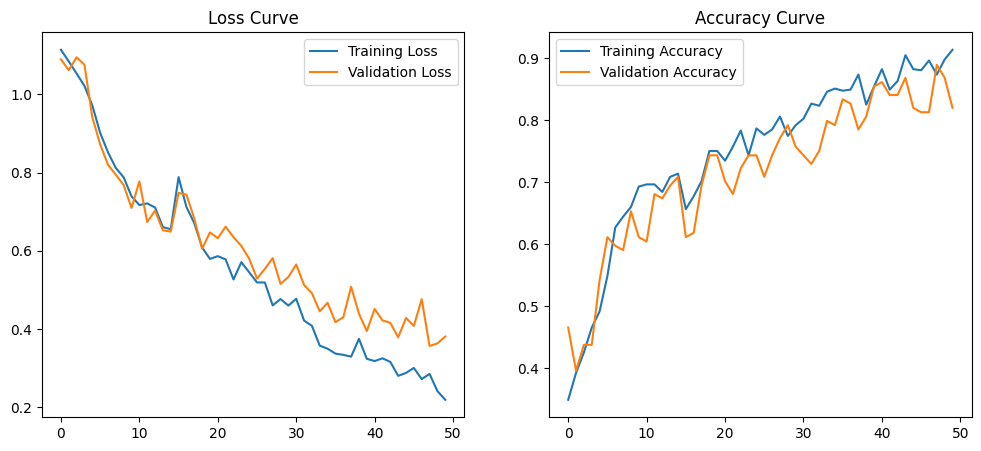

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")

plt.show()


# Test on unseen data

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the directory containing unseen test images
test_dataset_path = "/content/drive/MyDrive/Colab Notebooks/eye-images-balanced"

# Create a test data generator (without data augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load test images
test_generator = test_datagen.flow_from_directory(
    test_dataset_path,
    target_size=(100, 100),  # Match model input size
    batch_size=1,  # One image at a time for evaluation
    class_mode='categorical',
    shuffle=False  # Ensure order is maintained
)


Found 900 images belonging to 3 classes.


In [ ]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy on Unseen Data: {test_accuracy:.2f}")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


900/900 ━━━━━━━━━━━━━━━━━━━━ 108s 120ms/step - accuracy: 0.9056 - loss: 0.2660
Test Loss: 0.2247
Test Accuracy on Unseen Data: 0.92


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions from the model
y_pred_probs = model.predict(test_generator)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = test_generator.classes

# Get class labels mapping
class_indices = test_generator.class_indices
class_labels = {v: k for k, v in class_indices.items()}

# Print classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels.values()))

# Print confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))


116/900 ━━━━━━━━━━━━━━━━━━━━ 1:28 113ms/step